In [1]:
import numpy as np
import pandas as pd

# Direct relation matrix (A) từ bảng của bạn
A = np.array([
[0,3,3,4,3,1,3,3.67],
[3,0,3,4,3,2,4,3],
[2.33,1,0,1.33,2.33,3.67,2.33,2.67],
[1,2.67,1.67,0,4,3,2,2],
[3,4,3,3,0,3,4,2.33],
[3,2.67,3,1.33,1.33,0,2.67,2.67],
[2.33,2.67,2.33,1.67,1,1,0,3.33],
[2,2.67,3,3,2,2,3.33,0]
])

labels = ["B1","B2","B3","B4","B5","B6","B8","B9"]

# ===== Step 1: Normalize matrix =====
row_sum = np.max(np.sum(A, axis=1))

D = A / row_sum

# ===== Step 2: Compute Total Relation Matrix =====
I = np.eye(len(A))

T = np.dot(D, np.linalg.inv(I - D))

# = Convert to DataFrame =
T_df = pd.DataFrame(T, index=labels, columns=labels)

print("===== Normalized Matrix D =====")
print(pd.DataFrame(D, index=labels, columns=labels))

print("\n===== Total Relation Matrix T =====")
print(T_df.round(3))

=Normalized Matrix D =
          B1        B2        B3        B4        B5        B6        B8  \
B1  0.000000  0.134348  0.134348  0.179131  0.134348  0.044783  0.134348   
B2  0.134348  0.000000  0.134348  0.179131  0.134348  0.089566  0.179131   
B3  0.104344  0.044783  0.000000  0.059561  0.104344  0.164353  0.104344   
B4  0.044783  0.119570  0.074787  0.000000  0.179131  0.134348  0.089566   
B5  0.134348  0.179131  0.134348  0.134348  0.000000  0.134348  0.179131   
B6  0.134348  0.119570  0.134348  0.059561  0.059561  0.000000  0.119570   
B8  0.104344  0.119570  0.104344  0.074787  0.044783  0.044783  0.000000   
B9  0.089566  0.119570  0.134348  0.134348  0.089566  0.089566  0.149127   

          B9  
B1  0.164353  
B2  0.134348  
B3  0.119570  
B4  0.089566  
B5  0.104344  
B6  0.119570  
B8  0.149127  
B9  0.000000  

Total Relation Matrix T
       B1     B2     B3     B4     B5     B6     B8     B9
B1  0.463  0.636  0.643  0.668  0.591  0.491  0.705  0.688
B2  0.605  0.5

In [2]:
import numpy as np
import pandas as pd

labels = ["B1","B2","B3","B4","B5","B6","B8","B9"]

T = np.array([
[0.463,0.636,0.643,0.668,0.591,0.491,0.705,0.688],
[0.605,0.543,0.669,0.690,0.611,0.546,0.767,0.692],
[0.456,0.444,0.407,0.445,0.448,0.483,0.544,0.528],
[0.432,0.536,0.504,0.418,0.538,0.486,0.567,0.529],
[0.619,0.707,0.682,0.665,0.500,0.590,0.781,0.681],
[0.502,0.527,0.551,0.476,0.438,0.359,0.586,0.557],
[0.428,0.475,0.473,0.439,0.381,0.360,0.421,0.525],
[0.487,0.554,0.575,0.560,0.489,0.468,0.639,0.476]
])

# =DEMATEL calculations =

D = np.sum(T, axis=1)   # row sum
R = np.sum(T, axis=0)   # column sum

D_plus_R = D + R
D_minus_R = D - R

# classification
classification = ["Cause" if x>0 else "Effect" for x in D_minus_R]

# create result table
result = pd.DataFrame({
    "D":D,
    "R":R,
    "D+R":D_plus_R,
    "D-R":D_minus_R,
    "Classification":classification
}, index=labels)

print(result.round(3))

        D      R    D+R    D-R Classification
B1  4.885  3.992  8.877  0.893          Cause
B2  5.123  4.422  9.545  0.701          Cause
B3  3.755  4.504  8.259 -0.749         Effect
B4  4.010  4.361  8.371 -0.351         Effect
B5  5.225  3.996  9.221  1.229          Cause
B6  3.996  3.783  7.779  0.213          Cause
B8  3.502  5.010  8.512 -1.508         Effect
B9  4.248  4.676  8.924 -0.428         Effect


In [8]:
import numpy as np
import pandas as pd

# Total Relation Matrix (T) 
T = np.array([
[0.463,0.636,0.643,0.668,0.591,0.491,0.705,0.688],
[0.605,0.543,0.669,0.690,0.611,0.546,0.767,0.692],
[0.456,0.444,0.407,0.445,0.448,0.483,0.544,0.528],
[0.432,0.536,0.504,0.418,0.538,0.486,0.567,0.529],
[0.619,0.707,0.682,0.665,0.500,0.590,0.781,0.681],
[0.502,0.527,0.551,0.476,0.438,0.359,0.586,0.557],
[0.428,0.475,0.473,0.439,0.381,0.360,0.421,0.525],
[0.487,0.554,0.575,0.560,0.489,0.468,0.639,0.476]
])

# Remove diagona
values = T[~np.eye(T.shape[0], dtype=bool)]

# ===== Mean and SD threshold =====
mean_val = np.mean(values)
sd_val = np.std(values)

alpha_mean = mean_val
alpha_mean_sd = mean_val + sd_val

# ===== MMDE Calculation =====
alphas = np.unique(values)
alphas = np.sort(alphas)

results = []

for alpha in alphas:

    subset = values[values >= alpha]
    n = len(subset)

    if n <= 1:
        entropy = 0
        de_entropy = 0
        mean_de_entropy = 0

    else:

        p = subset / np.sum(subset)

        entropy = -np.sum(p * np.log(p))

        max_entropy = np.log(n)

        de_entropy = max_entropy - entropy

        mean_de_entropy = de_entropy / n

    results.append([alpha, n, entropy, de_entropy, mean_de_entropy])

df = pd.DataFrame(results, columns=[
"alpha_k",
"Elements (n)",
"Entropy",
"De-entropy",
"Mean De-entropy"
])

# ===== Best MMDE threshold =====
best = df.loc[df["Mean De-entropy"].idxmax()]

# ===== Print results =====
print("========== MMDE TABLE ==========")
print(df)

print("\n========== BEST MMDE THRESHOLD ==========")
print(f"Alpha (MMDE): {best['alpha_k']:.3f}")
print(f"Mean De-entropy value: {best['Mean De-entropy']:.6f}")

print("\n========== THRESHOLD COMPARISON ==========")
print(f"Mean threshold: {alpha_mean:.3f}")
print(f"Mean + SD threshold: {alpha_mean_sd:.3f}")

# ===== Summary table =====
summary = pd.DataFrame({
"Method":["MMDE","Mean","Mean + SD"],
"Threshold":[best['alpha_k'],alpha_mean,alpha_mean_sd]
})

print("\n========== SUMMARY ==========")
print(summary)

MMDE TABLE    alpha_k  Elements (n)   Entropy  De-entropy  Mean De-entropy
0     0.360            56  4.010064    0.015288         0.000273
1     0.381            55  3.993175    0.014159         0.000257
2     0.428            54  3.975726    0.013258         0.000246
3     0.432            53  3.957446    0.012846         0.000242
4     0.438            52  3.938803    0.012440         0.000239
5     0.439            51  3.919766    0.012059         0.000236
6     0.444            50  3.900368    0.011655         0.000233
7     0.445            49  3.880555    0.011266         0.000230
8     0.448            48  3.860350    0.010851         0.000226
9     0.456            47  3.839718    0.010429         0.000222
10    0.468            46  3.818593    0.010049         0.000218
11    0.473            45  3.796917    0.009745         0.000217
12    0.475            44  3.774734    0.009455         0.000215
13    0.476            43  3.752048    0.009152         0.000213
14    0.483    

In [18]:
import numpy as np
import pandas as pd

# Ma trận T 8x8 từ ảnh
labels = [1, 2, 3, 4, 5, 6, 8, 9] 
T = np.array([
    [0.463, 0.636, 0.643, 0.668, 0.591, 0.491, 0.705, 0.688], 
    [0.605, 0.543, 0.669, 0.690, 0.611, 0.546, 0.767, 0.692], 
    [0.456, 0.444, 0.407, 0.445, 0.448, 0.483, 0.544, 0.528], 
    [0.432, 0.536, 0.504, 0.418, 0.538, 0.486, 0.567, 0.529], 
    [0.619, 0.707, 0.682, 0.665, 0.500, 0.590, 0.781, 0.681], 
    [0.502, 0.527, 0.551, 0.476, 0.438, 0.359, 0.586, 0.557], 
    [0.428, 0.475, 0.473, 0.439, 0.381, 0.360, 0.421, 0.525], 
    [0.487, 0.554, 0.575, 0.560, 0.489, 0.468, 0.639, 0.476]  
])

def ism_level_partition_standard(T_matrix, alpha, node_labels):
    n = len(node_labels)
    B = (T_matrix >= alpha).astype(int)
    np.fill_diagonal(B, 1)

    # 1. Khởi tạo các tập hợp ban đầu (cố định toàn cục)
    full_reach = [set(j for j in range(n) if B[i, j] == 1) for i in range(n)]
    full_ante = [set(j for j in range(n) if B[j, i] == 1) for i in range(n)]

    remaining = set(range(n))
    node_to_level = {}
    iteration_results = []
    level_num = 1
    roman = {1:"I", 2:"II", 3:"III", 4:"IV", 5:"V", 6:"VI", 7:"VII", 8:"VIII"}

    # 2. Iteration chuẩn
    while remaining:
        current_level_nodes = []
        
        for i in sorted(list(remaining)):
            # Cập nhật theo iteration: R(Mi) và A(Mi) chỉ xét trong các nút còn lại
            r_current = full_reach[i].intersection(remaining)
            a_current = full_ante[i].intersection(remaining)
            inter_current = r_current.intersection(a_current)
            
            # Điều kiện chuẩn: R_current == Inter_current
            if r_current == inter_current:
                current_level_nodes.append(i)
                node_to_level[node_labels[i]] = roman[level_num]

        # Lưu dữ liệu cho bảng hiển thị
        for i in current_level_nodes:
            iteration_results.append({
                "Elements (Mi)": node_labels[i],
                "Reachability set R(Mi)": ", ".join(map(str, sorted([node_labels[x] for x in full_reach[i]]))),
                "Antecedent set A(Ni)": ", ".join(map(str, sorted([node_labels[x] for x in full_ante[i]]))),
                "Intersection set": ", ".join(map(str, sorted([node_labels[x] for x in full_reach[i].intersection(full_ante[i])]))),
                "Level": roman[level_num]
            })

        # Loại bỏ các nút đã phân tầng khỏi tập remaining cho vòng lặp tiếp theo
        remaining -= set(current_level_nodes)
        level_num += 1

    return pd.DataFrame(iteration_results).sort_values(by="Elements (Mi)")

# Tính toán cho 2 trường hợp
df_mean_sd = ism_level_partition_standard(T, 0.654, labels)
df_mmde = ism_level_partition_standard(T, 0.707, labels)

print("--- TABLE: MEAN + SD (Alpha = 0.654) ---")
print(df_mean_sd.to_string(index=False))
print("\n--- TABLE: MMDE (Alpha = 0.707) ---")
print(df_mmde.to_string(index=False))

--- TABLE: MEAN + SD (Alpha = 0.654) ---
 Elements (Mi) Reachability set R(Mi) Antecedent set A(Ni) Intersection set Level
             1             1, 4, 8, 9                    1                1    II
             2          2, 3, 4, 8, 9                 2, 5                2    II
             3                      3              2, 3, 5                3     I
             4                      4           1, 2, 4, 5                4     I
             5       2, 3, 4, 5, 8, 9                    5                5   III
             6                      6                    6                6     I
             8                      8           1, 2, 5, 8                8     I
             9                      9           1, 2, 5, 9                9     I

--- TABLE: MMDE (Alpha = 0.707) ---
 Elements (Mi) Reachability set R(Mi) Antecedent set A(Ni) Intersection set Level
             1                      1                    1                1     I
             2      

In [21]:
import numpy as np
import pandas as pd

# 1. Khởi tạo ma trận bài gốc (9x9) từ hình ảnh
labels = [1, 2, 3, 4, 5, 6, 7, 8, 9]
A = np.array([
    [0.00, 3.00, 3.00, 4.00, 3.00, 1.00, 3.00, 3.00, 3.67],
    [3.00, 0.00, 3.00, 4.00, 3.00, 2.00, 2.67, 4.00, 3.00],
    [2.33, 1.00, 0.00, 1.33, 2.33, 3.67, 1.00, 2.33, 2.67],
    [1.00, 2.67, 1.67, 0.00, 4.00, 3.00, 1.00, 2.00, 2.00],
    [3.00, 4.00, 3.00, 3.00, 0.00, 3.00, 1.33, 4.00, 2.33],
    [3.00, 2.67, 3.00, 1.33, 1.33, 0.00, 2.67, 2.67, 2.67],
    [2.33, 3.00, 1.00, 2.33, 0.00, 0.00, 0.00, 3.00, 1.00],
    [2.33, 2.67, 2.33, 1.67, 1.00, 1.00, 1.33, 0.00, 3.33],
    [2.00, 2.67, 3.00, 3.00, 2.00, 2.00, 1.00, 3.33, 0.00]
])

# --- BƯỚC 1: TÍNH TOÁN DEMATEL ---
# Tính k (hệ số chuẩn hóa)
k = max(A.sum(axis=1).max(), A.sum(axis=0).max())
D_norm = A / k

# Tính ma trận quan hệ tổng thể T = D * (I - D)^-1
I = np.eye(len(labels))
T = D_norm @ np.linalg.inv(I - D_norm)

# Tính các chỉ số D, R, D+R, D-R
D_val = T.sum(axis=1)
R_val = T.sum(axis=0)
D_plus_R = D_val + R_val
D_minus_R = D_val - R_val
classification = ["Cause" if val > 0 else "Effect" for val in D_minus_R]

# --- BƯỚC 2: XÁC ĐỊNH NGƯỠNG ALPHA (MEAN + SD) ---
off_diag = T[~np.eye(len(labels), dtype=bool)]
alpha = np.mean(off_diag) + np.std(off_diag)

# --- BƯỚC 3: PHÂN TẦNG ISM (STANDARD ITERATION) ---
# Tạo ma trận khả kiến B (Reachability Matrix)
B = (T >= alpha).astype(int)
np.fill_diagonal(B, 1) # Thêm quan hệ tự thân

# Khởi tạo tập Reachability và Antecedent đầy đủ ban đầu
full_reach = [set(j for j in range(len(labels)) if B[i, j] == 1) for i in range(len(labels))]
full_ante = [set(j for j in range(len(labels)) if B[j, i] == 1) for i in range(len(labels))]

remaining = set(range(len(labels)))
ism_data = []
level_num = 1
roman = {1: "I", 2: "II", 3: "III", 4: "IV", 5: "V", 6: "VI", 7: "VII"}

while remaining:
    current_level_nodes = []
    for i in remaining:
        # Quan trọng: Giao tập hợp với các phần tử còn lại (remaining)
        r_curr = full_reach[i].intersection(remaining)
        a_curr = full_ante[i].intersection(remaining)
        inter_curr = r_curr.intersection(a_curr)
        
        # Điều kiện phân tầng: Reachability (còn lại) == Intersection (còn lại)
        if r_curr == inter_curr:
            current_level_nodes.append(i)
    
    # Ghi nhận kết quả cho các node thuộc Level hiện tại
    for idx in current_level_nodes:
        ism_data.append({
            "Elements (Mi)": labels[idx],
            "Reachability set R(Mi)": ", ".join(map(str, sorted([labels[x] for x in full_reach[idx]]))),
            "Antecedent set A(Ni)": ", ".join(map(str, sorted([labels[x] for x in full_ante[idx]]))),
            "Intersection set": ", ".join(map(str, sorted([labels[x] for x in full_reach[idx].intersection(full_ante[idx])]))),
            "Level": roman[level_num]
        })
    
    # Loại bỏ các node đã phân tầng khỏi tập remaining
    remaining -= set(current_level_nodes)
    level_num += 1

# --- BƯỚC 4: HIỂN THỊ KẾT QUẢ ---
df_dematel = pd.DataFrame({
    "D": D_val,
    "R": R_val,
    "D+R": D_plus_R,
    "D-R": D_minus_R,
    "Classification": classification
}, index=[f"B{i}" for i in labels])

df_ism = pd.DataFrame(ism_data).sort_values(by="Elements (Mi)")

print(f"--- THRESHOLD ALPHA (MEAN + SD) ---")
print(f"Value: {alpha:.4f}\n")

print("--- TABLE 1: DEMATEL RESULTS ---")
print(df_dematel.round(3).to_string())

print("\n--- TABLE 2: ISM LEVEL PARTITIONING ---")
print(df_ism.to_string(index=False))

--- THRESHOLD ALPHA (MEAN + SD) ---
Value: 0.5016

--- TABLE 1: DEMATEL RESULTS ---
        D      R    D+R    D-R Classification
B1  4.263  3.472  7.734  0.791          Cause
B2  4.420  3.910  8.330  0.510          Cause
B3  3.130  3.704  6.834 -0.574         Effect
B4  3.323  3.794  7.117 -0.471         Effect
B5  4.350  3.189  7.539  1.161          Cause
B6  3.535  2.983  6.518  0.552          Cause
B7  2.396  2.604  5.000 -0.208         Effect
B8  2.960  4.377  7.337 -1.418         Effect
B9  3.515  3.859  7.373 -0.344         Effect

--- TABLE 2: ISM LEVEL PARTITIONING ---
 Elements (Mi) Reachability set R(Mi) Antecedent set A(Ni) Intersection set Level
             1       1, 2, 3, 4, 8, 9                    1                1    IV
             2          2, 3, 4, 8, 9              1, 2, 5                2   III
             3                      3           1, 2, 3, 5                3     I
             4                      4           1, 2, 4, 5                4     I
     

saved fig2_new.png
sigma=0.1: DI mean=0.4887 CV=9.9% | BDI-M mean=0.1836 CV=16.3%
sigma=0.15: DI mean=0.4698 CV=13.3% | BDI-M mean=0.1901 CV=24.7%


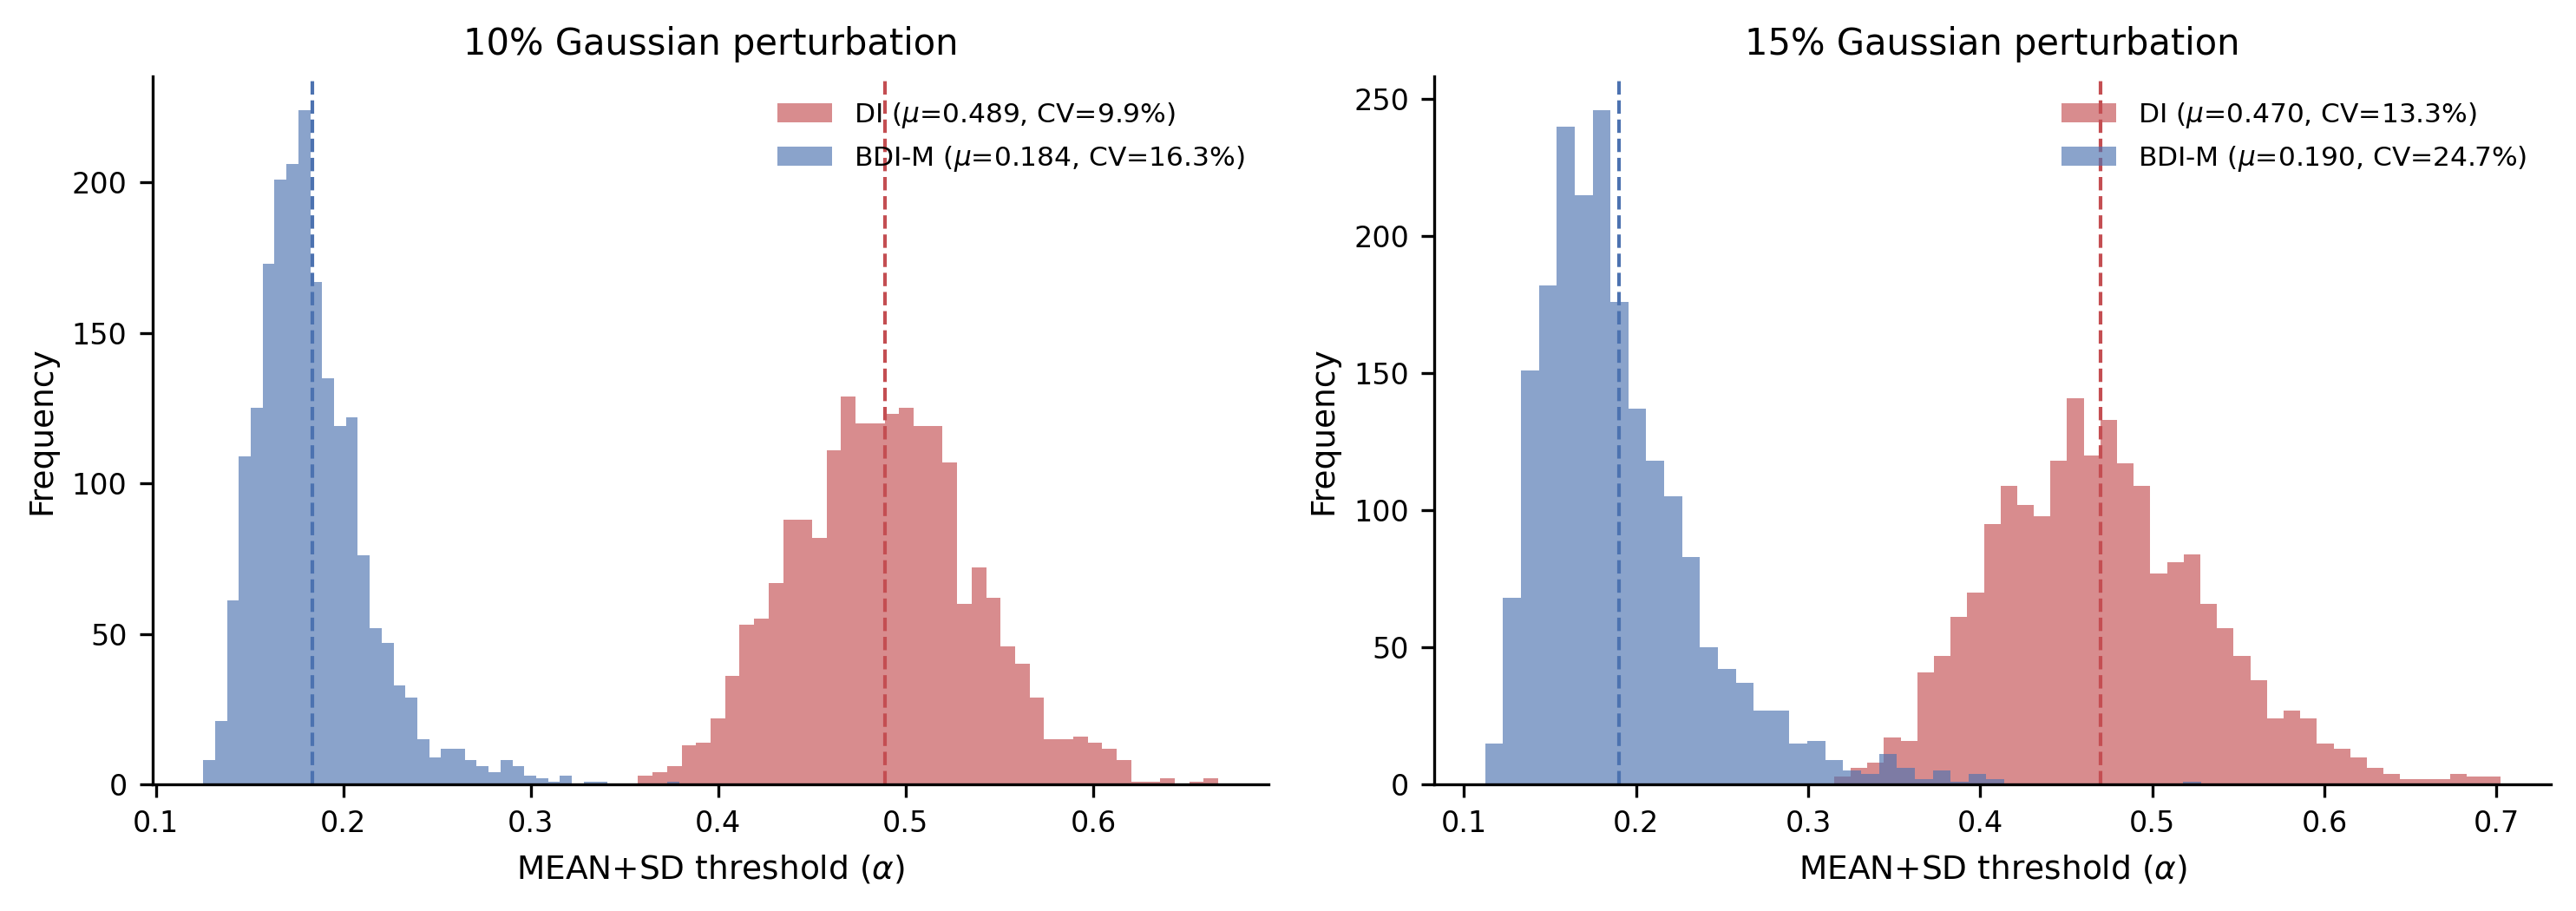

In [1]:
# -*- coding: utf-8 -*-
"""Fig. 2 (regenerated): MEAN+SD threshold distributions under perturbation.
Formulation consistent with Tables IV/V/VII: Z' = w*Z, normalized by max row sum of Z'.
DI: multiplicative Gaussian noise on the direct relation matrix.
BDI-M: multiplicative Gaussian noise on the BWM weight vector (re-normalized).
"""
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
w = np.array([0.121,0.184,0.067,0.148,0.120,0.093,0.022,0.142,0.103])
Z = np.array([
[0.00,3.00,3.00,4.00,3.00,1.00,3.00,3.00,3.67],
[3.00,0.00,3.00,4.00,3.00,2.00,2.67,4.00,3.00],
[2.33,1.00,0.00,1.33,2.33,3.67,1.00,2.33,2.67],
[1.00,2.67,1.67,0.00,4.00,3.00,1.00,2.00,2.00],
[3.00,4.00,3.00,3.00,0.00,3.00,1.33,4.00,2.33],
[3.00,2.67,3.00,1.33,1.33,0.00,2.67,2.67,2.67],
[2.33,3.00,1.00,2.33,0.00,0.00,0.00,3.00,1.00],
[2.33,2.67,2.33,1.67,1.00,1.00,1.33,0.00,3.33],
[2.00,2.67,3.00,3.00,2.00,2.00,1.00,3.33,0.00]])
n = 9; I = np.eye(n)

def msd_threshold(Zm):
    X = Zm / Zm.sum(axis=1).max()
    T = X @ np.linalg.inv(I - X)
    off = T[~np.eye(n, dtype=bool)]
    return off.mean() + off.std()

def simulate(model, sigma, iters=2000):
    rng = np.random.default_rng(42)
    out = []
    for _ in range(iters):
        if model == 'DI':
            Zp = np.maximum(Z * (1 + rng.normal(0, sigma, (n, n))), 0)
            np.fill_diagonal(Zp, 0)
            out.append(msd_threshold(Zp))
        else:
            wp = np.maximum(w * (1 + rng.normal(0, sigma, n)), 1e-6)
            wp /= wp.sum()
            out.append(msd_threshold(wp[:, None] * Z))
    return np.array(out)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), dpi=300)
for ax, sigma in zip(axes, [0.10, 0.15]):
    a_di  = simulate('DI', sigma)
    a_bdm = simulate('BDIM', sigma)
    ax.hist(a_di,  bins=40, alpha=0.65, color='#c44e52', label=f'DI ($\\mu$={a_di.mean():.3f}, CV={a_di.std()/a_di.mean()*100:.1f}%)')
    ax.hist(a_bdm, bins=40, alpha=0.65, color='#4c72b0', label=f'BDI-M ($\\mu$={a_bdm.mean():.3f}, CV={a_bdm.std()/a_bdm.mean()*100:.1f}%)')
    ax.axvline(a_di.mean(),  color='#c44e52', ls='--', lw=1)
    ax.axvline(a_bdm.mean(), color='#4c72b0', ls='--', lw=1)
    ax.set_title(f'{int(sigma*100)}% Gaussian perturbation', fontsize=10)
    ax.set_xlabel(r'MEAN+SD threshold ($\alpha$)', fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.legend(fontsize=7.5, frameon=False)
    ax.tick_params(labelsize=8)
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig2_new.png', bbox_inches='tight')
print('saved fig2_new.png')
for sigma in [0.10, 0.15]:
    a_di, a_bdm = simulate('DI', sigma), simulate('BDIM', sigma)
    print(f"sigma={sigma}: DI mean={a_di.mean():.4f} CV={a_di.std()/a_di.mean()*100:.1f}% | BDI-M mean={a_bdm.mean():.4f} CV={a_bdm.std()/a_bdm.mean()*100:.1f}%")